# الخطوة 1 — محاذاة صورتي MS وPAN

في هذه الـNotebook سننفّذ **المحاذاة الجغرافية فقط**، ولن نبدأ التدريب أو التقطيع بعد.

المدخلات:

- `MS_CLIP.tif`: صورة Multispectral منخفضة الدقة، 6 Bands.
- `PAN_CLIP_TIFF.tif`: صورة Panchromatic عالية الدقة، Band واحدة.

المخرجات:

- `MS_aligned.tif`
- `PAN_aligned.tif`

سنحافظ على صورة MS كما هي قدر الإمكان، ونُعيد وضع صورة PAN على شبكة تطابق MS بنسبة دقة `×4` بالضبط.


## 1) تثبيت المكتبات

شغّل الخلية التالية مرة واحدة.

In [1]:
!pip install -q rasterio matplotlib numpy

## 2) ربط Google Drive وتحديد المسارات

المسارات أدناه مطابقة للفولدرات التي استخدمتها. عدّلها فقط لو غيّرت أسماء الملفات أو المجلدات.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Super_Resolution_28-07-2026"
)

MS_PATH = PROJECT_DIR / "Law_Resolution" / "MS_CLIP.tif"
PAN_PATH = PROJECT_DIR / "High_Resolution" / "PAN_CLIP_TIFF.tif"

OUTPUT_DIR = PROJECT_DIR / "Aligned_Data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MS_OUT = OUTPUT_DIR / "MS_aligned.tif"
PAN_OUT = OUTPUT_DIR / "PAN_aligned.tif"

print("MS موجودة :", MS_PATH.exists(), MS_PATH)
print("PAN موجودة:", PAN_PATH.exists(), PAN_PATH)
print("Output folder:", OUTPUT_DIR)

if not MS_PATH.exists():
    raise FileNotFoundError("مسار MS غير صحيح.")
if not PAN_PATH.exists():
    raise FileNotFoundError("مسار PAN غير صحيح.")


Mounted at /content/drive
MS موجودة : True /content/drive/MyDrive/Super_Resolution_28-07-2026/Law_Resolution/MS_CLIP.tif
PAN موجودة: True /content/drive/MyDrive/Super_Resolution_28-07-2026/High_Resolution/PAN_CLIP_TIFF.tif
Output folder: /content/drive/MyDrive/Super_Resolution_28-07-2026/Aligned_Data


## 3) فحص المعلومات الأساسية

النتيجة المتوقعة تقريبًا:

- MS: `1806 × 1540` و6 Bands.
- PAN: `7222 × 6158` وBand واحدة.
- Scale factor قريب جدًا من `×4`.


In [3]:
import rasterio

with rasterio.open(MS_PATH) as ms, rasterio.open(PAN_PATH) as pan:
    print("MS")
    print("  Width × Height:", ms.width, "×", ms.height)
    print("  Bands:", ms.count)
    print("  Pixel size:", ms.res)
    print("  CRS:", ms.crs)
    print("  Bounds:", ms.bounds)

    print("\nPAN")
    print("  Width × Height:", pan.width, "×", pan.height)
    print("  Bands:", pan.count)
    print("  Pixel size:", pan.res)
    print("  CRS:", pan.crs)
    print("  Bounds:", pan.bounds)

    print("\nResolution ratio")
    print("  X:", ms.res[0] / pan.res[0])
    print("  Y:", ms.res[1] / pan.res[1])

    if ms.crs != pan.crs:
        raise ValueError("الـCRS مختلف بين الصورتين؛ أوقف التنفيذ وأرسل النتيجة.")


MS
  Width × Height: 1806 × 1540
  Bands: 6
  Pixel size: (1.3262052588e-05, 1.2394559926e-05)
  CRS: EPSG:4326
  Bounds: BoundingBox(left=31.30149717, bottom=29.97812296771396, right=31.32544843697393, top=29.99721059)

PAN
  Width × Height: 7222 × 6158
  Bands: 1
  Pixel size: (3.3155127856e-06, 3.0986529195e-06)
  CRS: EPSG:4326
  Bounds: BoundingBox(left=31.30149553, bottom=29.97813055532172, right=31.325440163337603, top=29.99721206)

Resolution ratio
  X: 4.000000436010986
  Y: 3.9999832985489685


## 4) إنشاء النسختين المتحاذيتين

ما يفعله الكود:

1. يحسب الجزء الجغرافي المشترك.
2. يختار Pixels كاملة من MS داخل الجزء المشترك.
3. يجعل أبعاد MS قابلة للقسمة على 4.
4. يقص MS من دون تغيير قيمها.
5. يعيد إسقاط PAN على شبكة جديدة تطابق MS بنسبة `×4` بالضبط.
6. يحفظ النتيجتين في فولدر `Aligned_Data`.

الملفات الأصلية لن تتغير.


In [5]:
import math
import numpy as np
import rasterio

from affine import Affine
from rasterio.coords import BoundingBox
from rasterio.windows import Window, transform as window_transform
from rasterio.warp import reproject
from rasterio.enums import Resampling


SCALE = 4


# حذف أي ملفات ناقصة نتجت عن المحاولة السابقة
for output_file in [MS_OUT, PAN_OUT]:
    if output_file.exists():
        output_file.unlink()
        print("تم حذف الملف غير المكتمل:", output_file)


with rasterio.open(MS_PATH) as ms_src, rasterio.open(PAN_PATH) as pan_src:

    # التأكد أن نظام الإحداثيات واحد
    if ms_src.crs != pan_src.crs:
        raise ValueError("الـCRS مختلف بين الصورتين.")

    # ---------------------------------------------
    # 1) حساب الجزء الجغرافي المشترك
    # ---------------------------------------------

    intersection = BoundingBox(
        left=max(ms_src.bounds.left, pan_src.bounds.left),
        bottom=max(ms_src.bounds.bottom, pan_src.bounds.bottom),
        right=min(ms_src.bounds.right, pan_src.bounds.right),
        top=min(ms_src.bounds.top, pan_src.bounds.top),
    )

    if (
        intersection.right <= intersection.left
        or intersection.top <= intersection.bottom
    ):
        raise ValueError("لا يوجد تداخل جغرافي بين الصورتين.")

    ms_res_x, ms_res_y = ms_src.res

    # ---------------------------------------------
    # 2) تحديد نافذة صحيحة داخل MS
    # ---------------------------------------------

    col_start = math.ceil(
        (intersection.left - ms_src.bounds.left) / ms_res_x - 1e-9
    )

    row_start = math.ceil(
        (ms_src.bounds.top - intersection.top) / ms_res_y - 1e-9
    )

    col_end = math.floor(
        (intersection.right - ms_src.bounds.left) / ms_res_x + 1e-9
    )

    row_end = math.floor(
        (ms_src.bounds.top - intersection.bottom) / ms_res_y + 1e-9
    )

    ms_width = col_end - col_start
    ms_height = row_end - row_start

    # جعل الأبعاد قابلة للقسمة على 4
    ms_width = (ms_width // SCALE) * SCALE
    ms_height = (ms_height // SCALE) * SCALE

    if ms_width <= 0 or ms_height <= 0:
        raise ValueError("الأبعاد الناتجة غير صالحة.")

    print("MS aligned size:")
    print("Width :", ms_width)
    print("Height:", ms_height)

    # ---------------------------------------------
    # 3) قراءة MS
    # ---------------------------------------------

    ms_window = Window(
        col_off=col_start,
        row_off=row_start,
        width=ms_width,
        height=ms_height,
    )

    aligned_ms_transform = window_transform(
        ms_window,
        ms_src.transform
    )

    aligned_ms = ms_src.read(window=ms_window)

    # ---------------------------------------------
    # 4) إنشاء شبكة PAN بنسبة ×4
    # ---------------------------------------------

    pan_width = ms_width * SCALE
    pan_height = ms_height * SCALE

    aligned_pan_transform = Affine(
        aligned_ms_transform.a / SCALE,
        0.0,
        aligned_ms_transform.c,
        0.0,
        aligned_ms_transform.e / SCALE,
        aligned_ms_transform.f,
    )

    aligned_pan = np.zeros(
        (pan_height, pan_width),
        dtype=np.uint16
    )

    reproject(
        source=rasterio.band(pan_src, 1),
        destination=aligned_pan,

        src_transform=pan_src.transform,
        src_crs=pan_src.crs,

        dst_transform=aligned_pan_transform,
        dst_crs=ms_src.crs,

        resampling=Resampling.bilinear,

        src_nodata=pan_src.nodata,
        dst_nodata=0,
    )

    # ---------------------------------------------
    # 5) تجهيز Profile ملف MS
    # ---------------------------------------------

    ms_profile = ms_src.profile.copy()

    # إزالة إعدادات Blocks القديمة غير المناسبة
    for key in [
        "blockxsize",
        "blockysize",
        "photometric",
        "interleave",
    ]:
        ms_profile.pop(key, None)

    ms_profile.update(
        driver="GTiff",
        width=ms_width,
        height=ms_height,
        count=ms_src.count,
        dtype=ms_src.dtypes[0],
        transform=aligned_ms_transform,
        crs=ms_src.crs,

        compress="deflate",
        predictor=2,

        tiled=True,
        blockxsize=256,
        blockysize=256,

        interleave="band",
        BIGTIFF="IF_SAFER",
    )

    with rasterio.open(MS_OUT, "w", **ms_profile) as dst:
        dst.write(aligned_ms)

    # ---------------------------------------------
    # 6) تجهيز Profile ملف PAN
    # ---------------------------------------------

    pan_profile = pan_src.profile.copy()

    for key in [
        "blockxsize",
        "blockysize",
        "photometric",
        "interleave",
    ]:
        pan_profile.pop(key, None)

    pan_profile.update(
        driver="GTiff",
        width=pan_width,
        height=pan_height,
        count=1,
        dtype="uint16",
        transform=aligned_pan_transform,
        crs=ms_src.crs,
        nodata=0,

        compress="deflate",
        predictor=2,

        tiled=True,
        blockxsize=256,
        blockysize=256,

        interleave="band",
        BIGTIFF="IF_SAFER",
    )

    with rasterio.open(PAN_OUT, "w", **pan_profile) as dst:
        dst.write(aligned_pan, 1)


print("\nتم الحفظ بنجاح:")
print("MS :", MS_OUT)
print("PAN:", PAN_OUT)

MS aligned size:
Width : 1804
Height: 1536

تم الحفظ بنجاح:
MS : /content/drive/MyDrive/Super_Resolution_28-07-2026/Aligned_Data/MS_aligned.tif
PAN: /content/drive/MyDrive/Super_Resolution_28-07-2026/Aligned_Data/PAN_aligned.tif


## 5) التأكد من الأبعاد والحدود

الشرط الأساسي:

```text
PAN width  = MS width  × 4
PAN height = MS height × 4
```

والحدود الجغرافية يجب أن تكون متطابقة تقريبًا.


In [6]:
with rasterio.open(MS_OUT) as ms, rasterio.open(PAN_OUT) as pan:
    print("MS aligned")
    print("  Shape:", ms.count, "Bands ×", ms.height, "×", ms.width)
    print("  Pixel size:", ms.res)
    print("  Bounds:", ms.bounds)

    print("\nPAN aligned")
    print("  Shape:", pan.count, "Band ×", pan.height, "×", pan.width)
    print("  Pixel size:", pan.res)
    print("  Bounds:", pan.bounds)

    print("\nChecks")
    print("  Width ratio :", pan.width / ms.width)
    print("  Height ratio:", pan.height / ms.height)
    print("  Same CRS:", pan.crs == ms.crs)

    bounds_difference = [
        abs(ms.bounds.left - pan.bounds.left),
        abs(ms.bounds.bottom - pan.bounds.bottom),
        abs(ms.bounds.right - pan.bounds.right),
        abs(ms.bounds.top - pan.bounds.top),
    ]

    print("  Maximum bounds difference:", max(bounds_difference))

    assert pan.width == ms.width * SCALE
    assert pan.height == ms.height * SCALE
    assert pan.crs == ms.crs

print("\nالاختبارات الأساسية نجحت.")


MS aligned
  Shape: 6 Bands × 1536 × 1804
  Pixel size: (1.3262052588e-05, 1.2394559926e-05)
  Bounds: BoundingBox(left=31.30149717, bottom=29.978172545953665, right=31.32542191286875, top=29.99721059)

PAN aligned
  Shape: 1 Band × 6144 × 7216
  Pixel size: (3.315513147e-06, 3.0986399815e-06)
  Bounds: BoundingBox(left=31.30149717, bottom=29.978172545953665, right=31.32542191286875, top=29.99721059)

Checks
  Width ratio : 4.0
  Height ratio: 4.0
  Same CRS: True
  Maximum bounds difference: 0.0

الاختبارات الأساسية نجحت.


## 6) عرض صورة MS المتحاذية

نستخدم Bands `3-2-1` للعرض المبدئي فقط. هذا لا يثبت رسميًا ترتيب الـBands.


In [7]:
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

def stretch_band(band):
    band = band.astype(np.float32)
    valid = band[np.isfinite(band) & (band > 0)]

    if valid.size == 0:
        return np.zeros_like(band, dtype=np.float32)

    low, high = np.percentile(valid, [2, 98])

    if high <= low:
        return np.zeros_like(band, dtype=np.float32)

    return np.clip((band - low) / (high - low), 0, 1)

with rasterio.open(MS_OUT) as src:
    preview_h = 900
    preview_w = round(src.width * preview_h / src.height)

    ms_preview = src.read(
        [3, 2, 1],
        out_shape=(3, preview_h, preview_w),
        resampling=Resampling.bilinear,
    )

rgb_preview = np.stack(
    [
        stretch_band(ms_preview[0]),
        stretch_band(ms_preview[1]),
        stretch_band(ms_preview[2]),
    ],
    axis=-1,
)

plt.figure(figsize=(14, 12))
plt.imshow(rgb_preview)
plt.title("Aligned MS — RGB 3-2-1 Preview")
plt.axis("off")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## 7) عرض صورة PAN المتحاذية

يجب أن تعرض المنطقة نفسها الموجودة في MS، ولكن بتفاصيل مكانية أعلى.


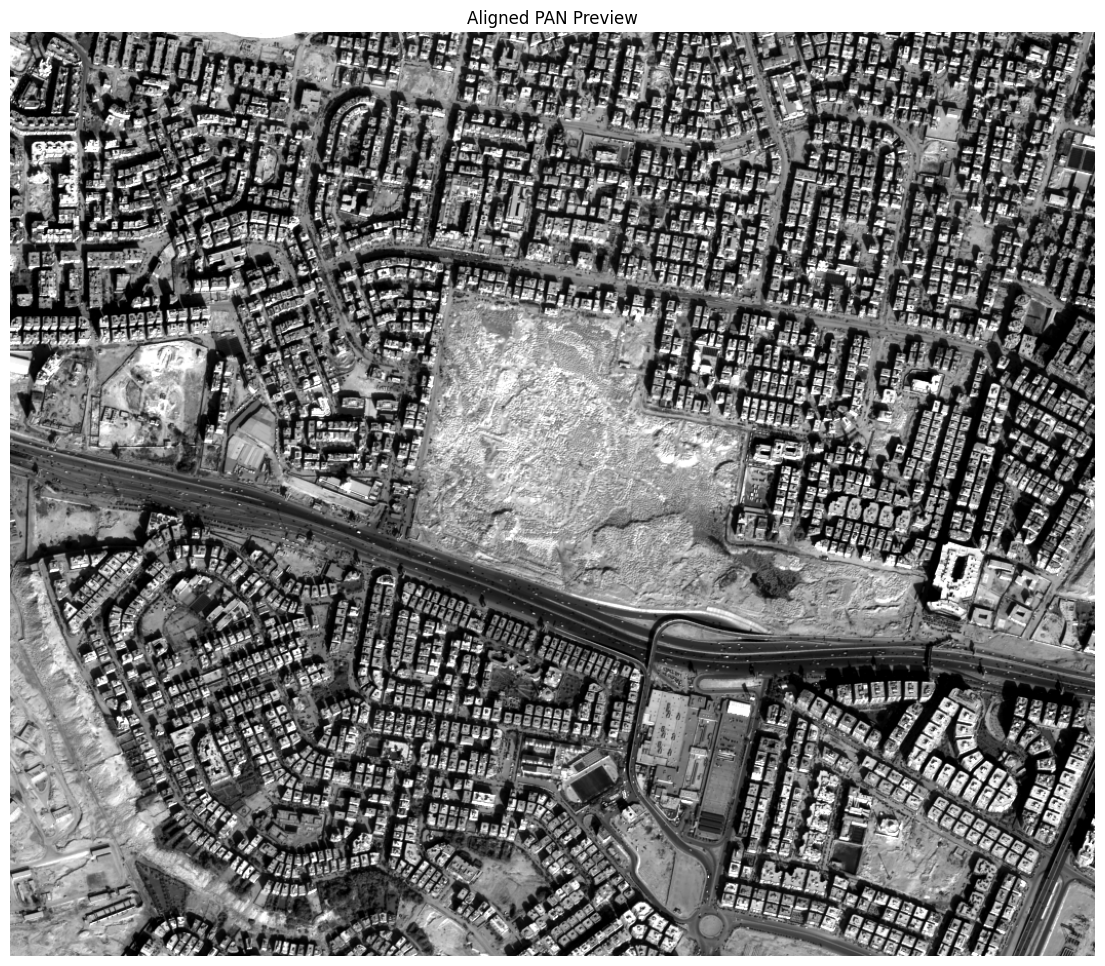

In [8]:
with rasterio.open(PAN_OUT) as src:
    preview_h = 900
    preview_w = round(src.width * preview_h / src.height)

    pan_preview = src.read(
        1,
        out_shape=(preview_h, preview_w),
        resampling=Resampling.bilinear,
    )

pan_preview = stretch_band(pan_preview)

plt.figure(figsize=(14, 12))
plt.imshow(pan_preview, cmap="gray")
plt.title("Aligned PAN Preview")
plt.axis("off")
plt.show()


## 8) فحص نفس الجزء من الصورتين

هذه الخلية تعرض جزءًا من منتصف الصورة. الهدف هو التأكد بصريًا أن الطرق والمباني تظهر في الموضع نفسه.

الصورة الأولى MS مكبرة للعرض، والصورة الثانية PAN.


In [9]:
from rasterio.windows import Window

with rasterio.open(MS_OUT) as ms_src, rasterio.open(PAN_OUT) as pan_src:

    crop_w = min(300, ms_src.width)
    crop_h = min(300, ms_src.height)

    ms_x = (ms_src.width - crop_w) // 2
    ms_y = (ms_src.height - crop_h) // 2

    ms_window = Window(ms_x, ms_y, crop_w, crop_h)

    ms_crop = ms_src.read(
        [3, 2, 1],
        window=ms_window,
        out_shape=(3, crop_h * SCALE, crop_w * SCALE),
        resampling=Resampling.bilinear,
    )

    pan_window = Window(
        ms_x * SCALE,
        ms_y * SCALE,
        crop_w * SCALE,
        crop_h * SCALE,
    )

    pan_crop = pan_src.read(1, window=pan_window)

ms_crop_rgb = np.stack(
    [
        stretch_band(ms_crop[0]),
        stretch_band(ms_crop[1]),
        stretch_band(ms_crop[2]),
    ],
    axis=-1,
)

pan_crop_show = stretch_band(pan_crop)

plt.figure(figsize=(12, 10))
plt.imshow(ms_crop_rgb)
plt.title("MS Center Crop — Upsampled only for viewing")
plt.axis("off")
plt.show()

plt.figure(figsize=(12, 10))
plt.imshow(pan_crop_show, cmap="gray")
plt.title("PAN Center Crop — Same Geographic Area")
plt.axis("off")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

# بعد انتهاء التشغيل

أرسل لي فقط:

1. ناتج خلية **فحص الأبعاد والحدود**.
2. صورة `Aligned MS — RGB 3-2-1 Preview`.
3. صورة `Aligned PAN Preview`.
4. صورتي الجزء الأوسط من MS وPAN.

بعد التأكد من المحاذاة، ستكون الخطوة التالية منفصلة: **إنشاء بيانات التدريب بطريقة Wald Protocol وتقطيعها إلى Train / Validation / Test**.
